# A Comparison of Fuel Break Layouts for Bushfire Control
**CITS4403 demo**

**Chao Jiang 25154863**
**Zihang Jiang 25349415**

**Research question:** Under the same treated area, does one wide fuel break or two narrow fuel breaks reduce fire impacts more effectively, and how does the gap between the two breaks affect their performance?

**Research aim:** This project aims to compare one wide fuel break with two narrow fuel breaks of the same total treated area. It examines how the gap between the two breaks affects fuel loss, burned area, and fire spread into a protected region over 100 simulation steps. The comparison uses two landscape maps, three treatment areas, and five wind conditions, with repeated runs to assess variation.

## 1. Model — How fire spreads

Each cell is **unburned, burning or burned out**. A burning cell can ignite its eight neighbours. More target fuel raises the chance of ignition. Wind and uphill spread also affect this chance.

$$p_{ij}=\mathrm{clip}\left(\frac{0.2F_j}{d_{ij}}e^{0.5\cos\phi+\theta_{ij}},0,1\right)$$

$F_j$ is target fuel; $d$ is 1 or $\sqrt{2}$; $\phi$ is the angle to the wind; $\theta$ is the uphill angle in radians. Set the wind term to zero with no wind. With several burning neighbours, the total chance is $1-\prod_i(1-p_{ij})$.

All cells update together. Each burning cell uses up to **0.2 fuel units per step**. Treatment leaves **20% of the original fuel**. The model has no flying embers or firefighting. These are model rules, not a calibrated forecast.

In [1]:
# Setup — run this cell before any chart.
from pathlib import Path
import sys, json, hashlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src/compare_100.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils.io import load_map, map_file
from utils.repeat_stats import summarize
from utils.notebook_analysis import (
    load_demo, save_figure, map_figure, layout_figure,
    area_figure, gap_figure, curve_figure, saved_animation)

FIGURES = ROOT / "notebooks/figures"
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
raw, config = load_demo(ROOT)
summary, pairs = summarize(raw)
lookup = {(s["group"], s["layout"]): s for s in summary}

def table(headers, rows):
    display(Markdown("| " + " | ".join(headers) + " |\n| " +
        " | ".join(["---"] * len(headers)) + " |\n" +
        "\n".join("| " + " | ".join(map(str, row)) + " |" for row in rows)))

# Check the saved experiment without running fire simulations.
assert len(raw) == 4800 and len(summary) == 480 and len(pairs) == 450
assert all(s["runs"] == 10 for s in summary)
assert {g["map"] for g in config["groups"]} == {"M1", "M2"}
from src.compare_100 import layout_specs
for area in (2, 4, 6):
    for label, bands in layout_specs(area):
        assert sum(w * 100 for c, w in bands) == area * 100
for row in raw:
    totals = np.array([x["total_cells"] for x in row["curve"]])
    assert len(totals) == 101 and (np.diff(totals) >= 0).all()
    assert totals[-1] == row["burned_cells"]
    assert 0 <= row["protected_fraction"] <= 1
for name in ("M1", "M2"):
    for filename in ("base_relative_fuel.csv", "height_grid.csv"):
        path = map_file(ROOT, name, filename)
        assert hashlib.sha256(path.read_bytes()).hexdigest() == config["sha256"][str(path.relative_to(ROOT))]
print("Ready. Saved results loaded; no fire simulations run.")


Ready. Saved results loaded; no fire simulations run.


## 2. The maps

Each map has **100 × 100 cells**. Source cells are 90 m wide; model distances use cell units.

- **M1:** gentler slopes; fuel is mostly 1.44.
- **M2:** steeper slopes; includes water and bare ground.

Vegetation classes come from CSIRO BFC [2]. Heights come from Esri [3]. Fuel values use literature-based estimates [4–6]. The dashed line shows where the first band starts.

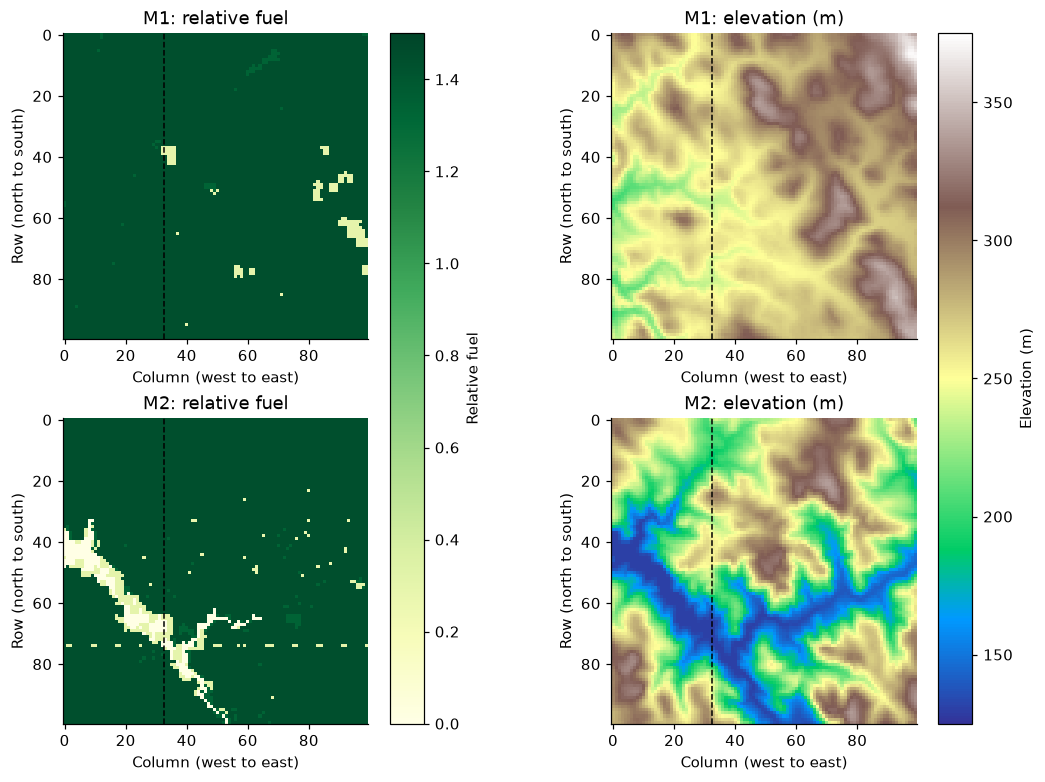

In [2]:
save_figure(map_figure(ROOT), FIGURES, "01_maps")
plt.show()

## 3. The experiment

| Factor | Settings |
|---|---|
| Maps | M1, M2 |
| Wind toward | None, east, south, west, north |
| Treated area | 2%, 4%, 6% |
| Layouts | One wide band; two narrow bands with gaps 1–15 |
| Repeats | 10 per case |
| Duration | 100 steps |

**Total: 2 × 5 × 3 × 16 × 10 = 4,800 runs.**

The first band always starts at column 33. Within each repeat, layouts share the same left-side ignition and random seed. Starts differ between groups.

Below is the 6% example: one width-6 band versus two width-3 bands. Gold is treatment; green is the protected region, columns 55–99. The star is only an example ignition.

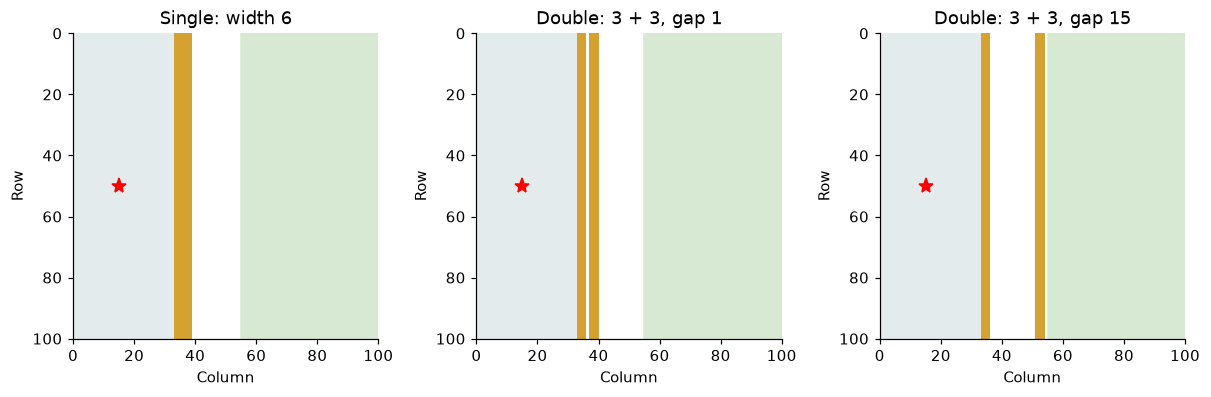

In [3]:
save_figure(layout_figure(), FIGURES, "02_layouts")
plt.show()

## 4. Main result: one wide band usually performs better

We compare fuel consumed, cells that caught fire, and the share of the protected region that caught fire. Fuel removed before ignition is not counted as fuel consumed.

There are **450 double-versus-single comparisons**. Single bands have lower mean fuel consumption in **432 (96%)**.

The plot averages the five wind groups. The gap between layouts is small at 2% area and larger at 4–6%.

| Outcome | Single lower mean | Double lower mean | Tie | CI supports single | CI supports double |
| --- | --- | --- | --- | --- | --- |
| Fuel consumed | 432 | 18 | 0 | 331 | 0 |
| Ever-ignited cells | 438 | 12 | 0 | 352 | 0 |
| Protected fraction | 421 | 19 | 10 | 261 | 0 |

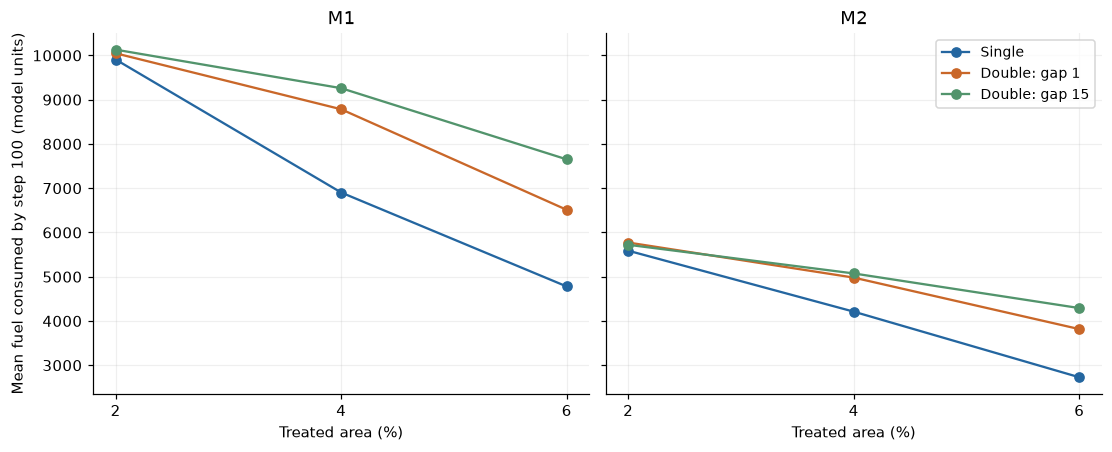

In [4]:
rows=[]
for field,label in [("total_fuel_burned","Fuel consumed"),("burned_cells","Ever-ignited cells"),("protected_fraction","Protected fraction")]:
    values=[p[field] for p in pairs]
    rows.append([label, sum(v["mean"]>1e-9 for v in values),
        sum(v["mean"] < -1e-9 for v in values),sum(abs(v["mean"])<=1e-9 for v in values),
        sum(v["low"]>0 for v in values),sum(v["high"]<0 for v in values)])
table(["Outcome", "Single lower mean", "Double lower mean", "Tie", "CI supports single", "CI supports double"], rows)

save_figure(area_figure(summary), FIGURES, "03_area")
plt.show()

## 5. Does a larger gap help?

Each square below shows **mean fuel consumed by double bands minus single bands**. Red favours the single band; blue favours double bands. Both maps use the same colour scale.

Larger gaps do not give a clear benefit. M1 often gets worse as the gap grows; M2 is less regular. There is **no single best gap across all settings**. Changing the gap also moves the second band.

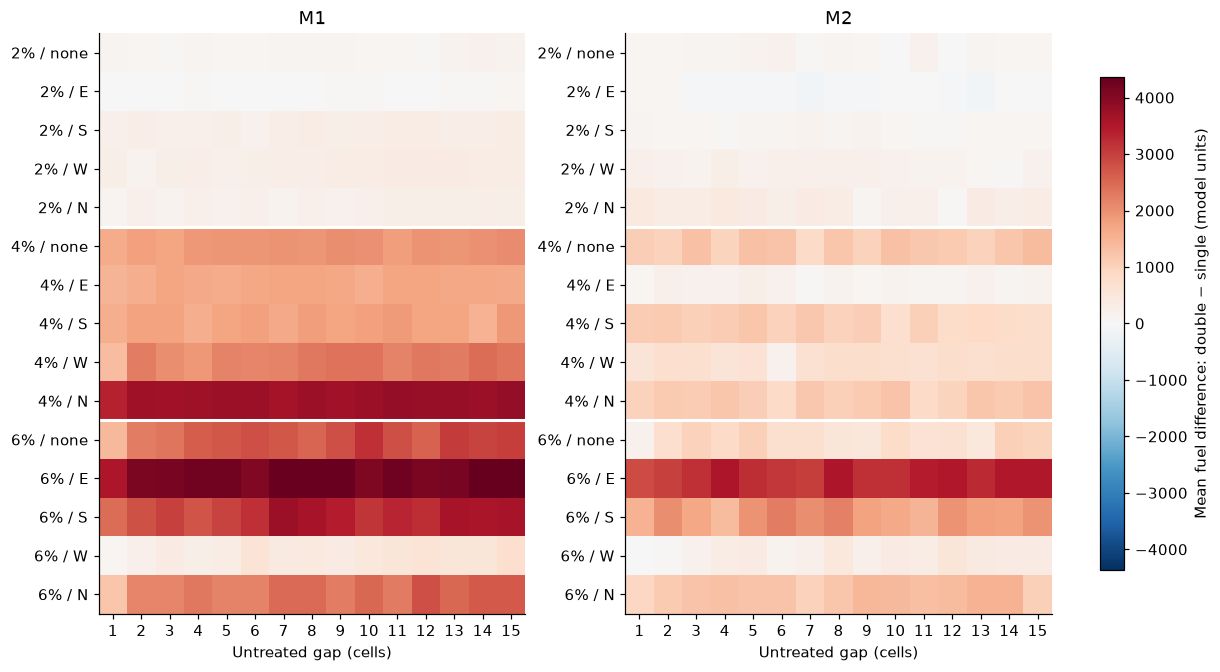

In [5]:
save_figure(gap_figure(pairs), FIGURES, "04_all_gaps")
plt.show()

## 6. One example: M1, no wind, 6% area

For the single band, mean protected-area burning is **0.15%**. For double bands with gap 6, it is **27.30%**. Fire reaches column 55 in **1/10** single runs and **9/10** double runs.

The curves show ten-run means. Shading shows one sample standard deviation: wider shading means more variation between runs. It is not a confidence interval.

The animation shows **only the first run**, not an average. Watch whether fire spreads again in the untreated gap after crossing the first narrow band. This may help explain the result.

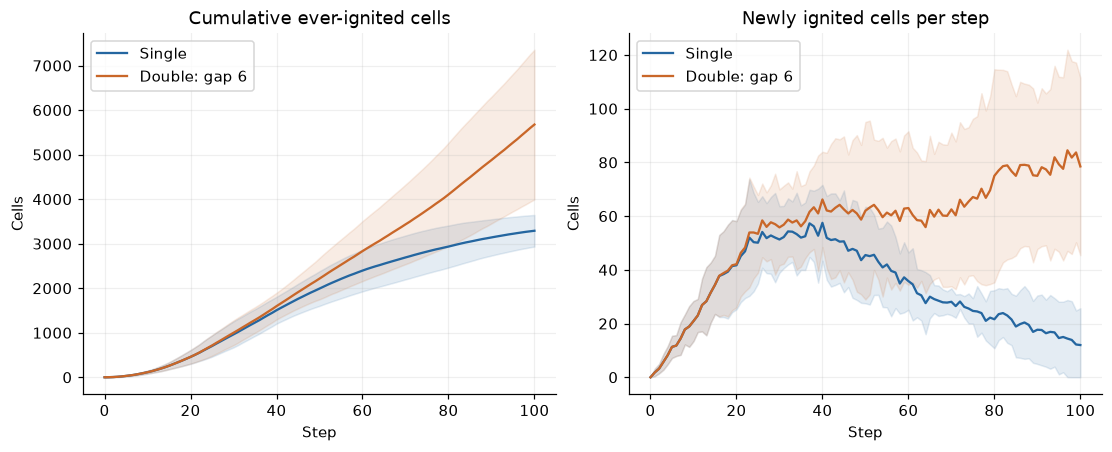

In [6]:
GROUP = "M1_none_a6"
GAP = 6
save_figure(curve_figure(summary, GROUP, GAP), FIGURES, "06_progression")
plt.show()


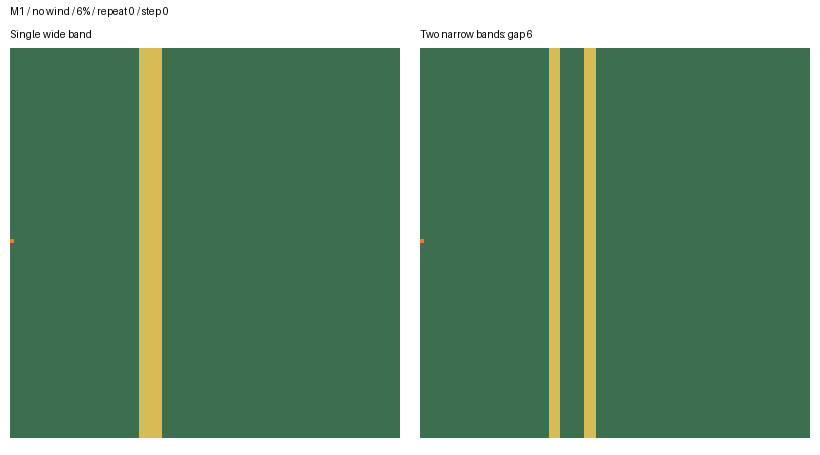

In [7]:
from IPython.display import HTML
import base64
gif = saved_animation(ROOT, FIGURES / "recorded_M1_none_a6.gif")
encoded = base64.b64encode(gif.read_bytes()).decode("ascii")
display(HTML(f'<img alt="Recorded single versus double band fire replay" src="data:image/gif;base64,{encoded}" style="max-width:100%;">'))

## 7. Conclusions

1. **One wide band usually gives lower fuel loss.** Its mean loss was lower in **432/450** comparisons. The advantage was larger at higher treated areas in the current data. Lower mean loss does not always mean less variation between runs.

2. **On M1, larger gaps generally led to higher fuel loss.** At 6% treatment, mean loss rose from **6,512 units at gap 1 to 7,651 at gap 15**, averaged across five wind settings. The trend was not strictly increasing. Changing the gap also moves the second band.

3. **The gap effect was less clear on M2.** Water and bare ground may have changed fire paths, but we did not test their effect separately. This is a possible explanation, not a proven cause.

These conclusions apply to the tested model and the first **100 steps**, not to all real fires.

## 8. Limits and next steps

**89% of runs are still burning at step 100.** We show short-term effects, not final fire size or permanent blocking.

M1 and M2 differ in both fuel and terrain. Wind groups also have different starts. We cannot say slope or wind alone caused their differences. Equal area does not mean equal fuel removed.

There is no untreated control, and the model has not been checked against a real fire. Full-height bands cannot be bypassed at their ends inside the map.

**Next:** use the same starts across wind settings, add untreated and flat-map controls, test spread and treatment parameters, and run active fires longer.

## References and data

[1] Finney (2001). *Design of Regular Landscape Fuel Treatment Patterns for Modifying Fire Growth and Behavior*. [Paper](https://doi.org/10.1093/forestscience/47.2.219).

[2] CSIRO. *Bushfire Fuel Classification, Release 2.0*. [Dataset](https://doi.org/10.25919/g8n4-3c18).

[3] Esri. *Terrain3D*. [Elevation service](https://elevation3d.arcgis.com/arcgis/rest/services/WorldElevation3D/Terrain3D/ImageServer).

[4] JBS&G (2024). *North Stoneville Structure Plan 34: Bushfire Simulation Modelling Report*, Table 2, pp. 22–23. [Report](https://www.wa.gov.au/system/files/2024-07/appendix-9-bushfire-simulation-modelling-report.pdf).

[5] Strategen (2016). *Bushfire hazard and BAL assessment, Breakwater Drive, Two Rocks*, section 2.2.1 and Table 1. [Report](https://www.wanneroo.wa.gov.au/download/downloads/id/2074/breakwater_drive_two_rocks_fire_management_plan_wapc_ref_152105.pdf).

[6] Kenny et al. (2024). *Australian Fire Danger Rating System: implementing fire behaviour calculations to forecast fire danger in a research prototype*. [Paper](https://doi.org/10.1071/WF23142).